In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from google.colab import drive

drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive/'

df = pd.read_csv('/content/drive/MyDrive/df_processed.csv')
X_train = pd.read_csv('/content/drive/MyDrive/X_train.csv')
X_test = pd.read_csv('/content/drive/MyDrive/X_test.csv')

X_train_scaled = np.load('/content/drive/MyDrive/X_train_lasso.npy')
X_test_scaled = np.load('/content/drive/MyDrive/X_test_lasso.npy')

print(f"df shape: {df.shape}")
print(f"X_train shape: {X_train.shape}")

Mounted at /content/drive
df shape: (11495, 40)
X_train shape: (9196, 37)


Running elbow method (k=2 to 10)...


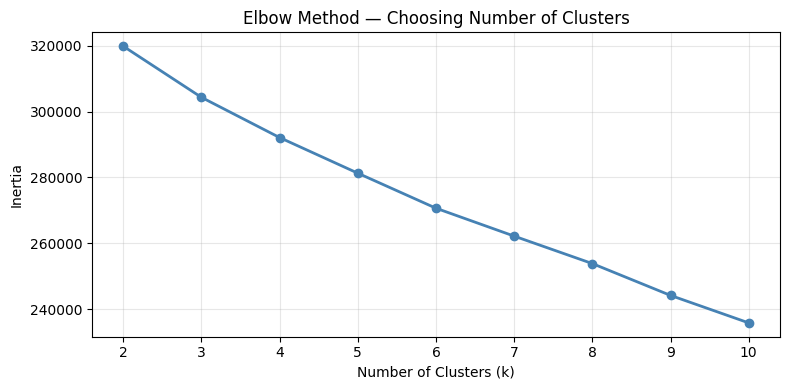

In [ ]:
print("Running elbow method (k=2 to 10)...")

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Method — Choosing Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DRIVE + 'elbow_plot.png', dpi=150)
plt.show()

  k=2, silhouette=0.0621
  k=3, silhouette=0.0705
  k=4, silhouette=0.0750
  k=5, silhouette=0.0857
  k=6, silhouette=0.0870
  k=7, silhouette=0.0776
  k=8, silhouette=0.0883
  k=9, silhouette=0.0876
  k=10, silhouette=0.0934


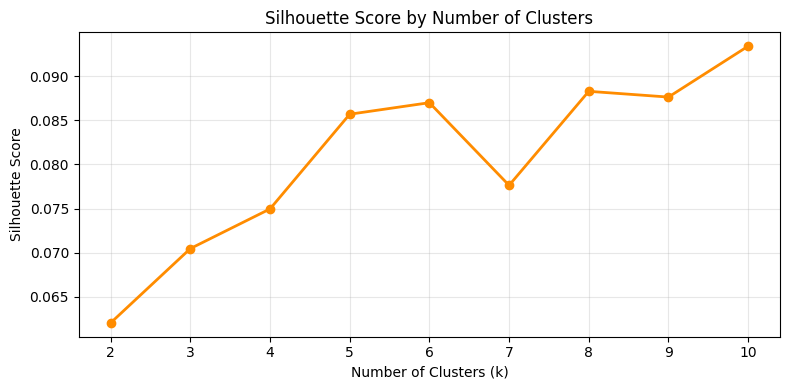


Best k by silhouette score: 10


In [ ]:
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    score = silhouette_score(X_train_scaled, labels)
    sil_scores.append(score)
    print(f"  k={k}, silhouette={score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), sil_scores, marker='o', linewidth=2, color='darkorange')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DRIVE + 'silhouette_plot.png', dpi=150)
plt.show()

best_k = k_range[np.argmax(sil_scores)]
print(f"\nBest k by silhouette score: {best_k}")

In [ ]:
CHOSEN_K = 3

km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
train_clusters = km_final.fit_predict(X_train_scaled)
test_clusters = km_final.predict(X_test_scaled)

print(f"K-Means fitted with k={CHOSEN_K}")
print(f"\nCluster distribution in training set:")
unique, counts = np.unique(train_clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} movies ({count/len(train_clusters)*100:.1f}%)")

K-Means fitted with k=3

Cluster distribution in training set:
  Cluster 0: 4657 movies (50.6%)
  Cluster 1: 680 movies (7.4%)
  Cluster 2: 3859 movies (42.0%)


Variance explained by 2 PCA components: 18.0%


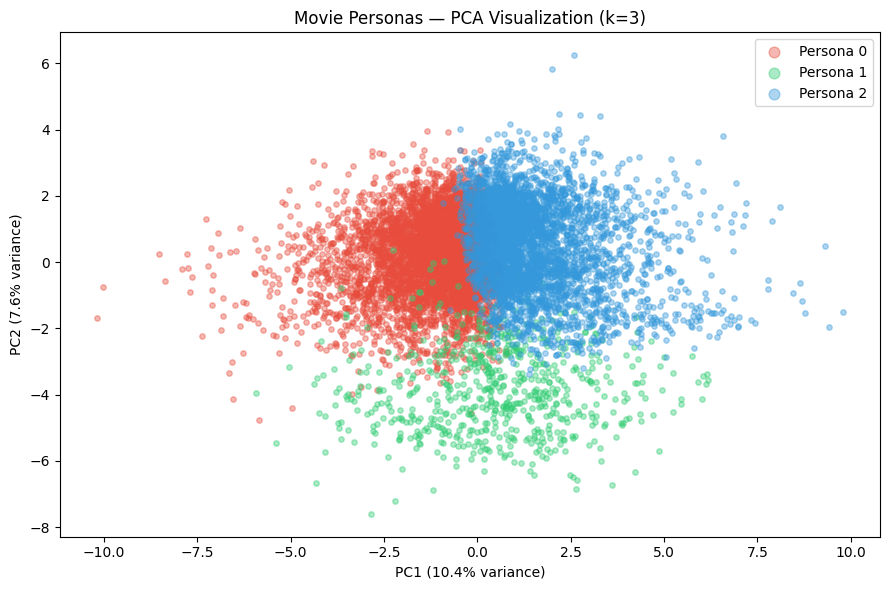

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

print(f"Variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(9, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']
labels_map = {0: 'Persona 0', 1: 'Persona 1', 2: 'Persona 2'}

for cluster_id in range(CHOSEN_K):
    mask = train_clusters == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster_id],
        label=labels_map[cluster_id],
        alpha=0.4, s=15
    )

plt.title(f'Movie Personas — PCA Visualization (k={CHOSEN_K})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig(DRIVE + 'pca_clusters.png', dpi=150)
plt.show()

Cluster profiles (scaled means):
         log_budget  log_popularity  imdb_rating  vote_count  runtime  \
cluster                                                                 
0            -0.427          -0.572       -0.363      -0.406   -0.235   
1             0.518           0.470       -0.040       0.284   -0.719   
2             0.424           0.608        0.445       0.440    0.410   

         is_english  
cluster              
0            -0.154  
1            -0.058  
2             0.196  


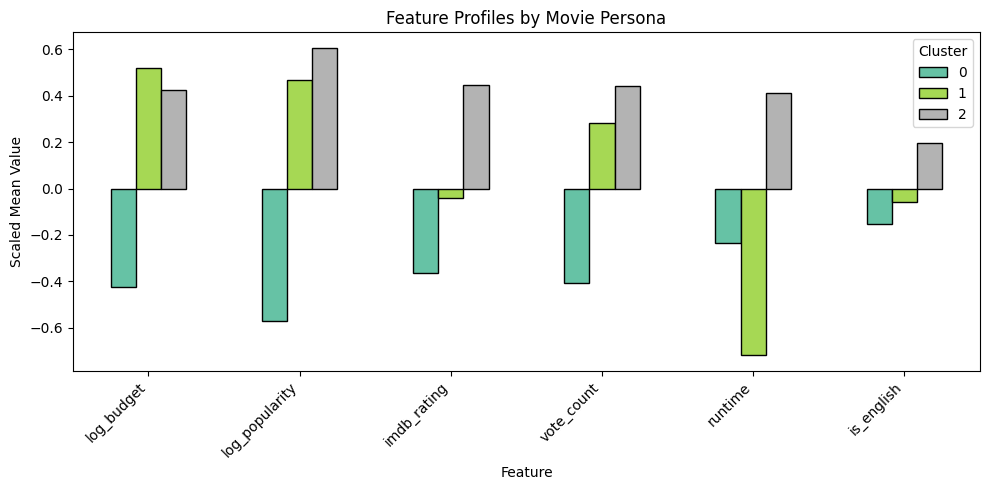

In [ ]:
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_train_df['cluster'] = train_clusters

key_features = ['log_budget', 'log_popularity', 'imdb_rating',
                'vote_count', 'runtime', 'is_english']
key_features = [f for f in key_features if f in X_train_df.columns]

cluster_profiles = X_train_df.groupby('cluster')[key_features].mean()
print("Cluster profiles (scaled means):")
print(cluster_profiles.round(3))

cluster_profiles.T.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Feature Profiles by Movie Persona')
plt.xlabel('Feature')
plt.ylabel('Scaled Mean Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig(DRIVE + 'cluster_profiles.png', dpi=150)
plt.show()

In [ ]:
persona_names = {
    0: 'Mid-Budget Commercial',
    1: 'Mainstream Blockbusters',
    2: 'Indie / Low-Visibility'
}

for cluster_id, name in persona_names.items():
    mask = train_clusters == cluster_id
    count = mask.sum()
    print(f"  Cluster {cluster_id} → '{name}': {count} movies")

  Cluster 0 → 'Mid-Budget Commercial': 4657 movies
  Cluster 1 → 'Mainstream Blockbusters': 680 movies
  Cluster 2 → 'Indie / Low-Visibility': 3859 movies


Success rate per persona:
  Mid-Budget Commercial (Cluster 0): 35.8% success rate (4657 movies)
  Mainstream Blockbusters (Cluster 1): 51.0% success rate (680 movies)
  Indie / Low-Visibility (Cluster 2): 53.8% success rate (3859 movies)


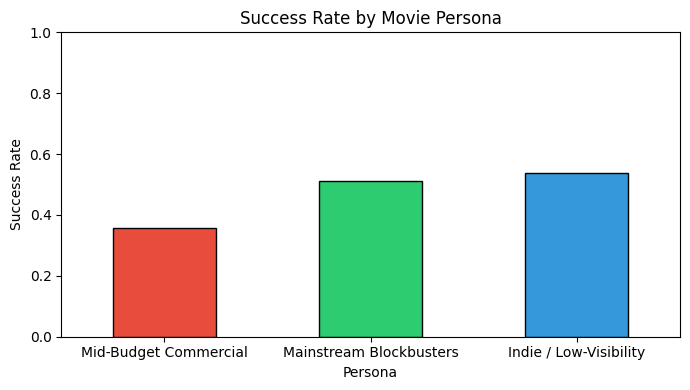

In [ ]:
y_train = pd.read_csv('/content/drive/MyDrive/y_train.csv').squeeze()

X_train_df['success'] = y_train.values

print("Success rate per persona:")
for cluster_id, name in persona_names.items():
    mask = X_train_df['cluster'] == cluster_id
    rate = X_train_df.loc[mask, 'success'].mean()
    count = mask.sum()
    print(f"  {name} (Cluster {cluster_id}): {rate:.1%} success rate ({count} movies)")

success_by_cluster = X_train_df.groupby('cluster')['success'].mean()
success_by_cluster.index = [persona_names[i] for i in success_by_cluster.index]

success_by_cluster.plot(kind='bar', color=['#e74c3c', '#2ecc71', '#3498db'],
                         edgecolor='black', figsize=(7, 4))
plt.title('Success Rate by Movie Persona')
plt.xlabel('Persona')
plt.ylabel('Success Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(DRIVE + 'success_by_persona.png', dpi=150)
plt.show()

In [ ]:
np.save('/content/drive/MyDrive/train_clusters.npy', train_clusters)
np.save('/content/drive/MyDrive/test_clusters.npy', test_clusters)

X_train_df.to_csv('/content/drive/MyDrive/X_train_clustered.csv', index=False)

print(f"Train clusters shape: {train_clusters.shape}")
print(f"Test clusters shape:  {test_clusters.shape}")

Train clusters shape: (9196,)
Test clusters shape:  (2299,)


In [ ]:
genre_cols = [c for c in X_train_df.columns if c.startswith('genre_')]

genre_summary = (
    X_train_df
    .groupby('cluster')[genre_cols]
    .mean()
    .T
)

print(genre_summary.round(3))

cluster                    0      1      2
genre_Action          -0.219 -0.190  0.297
genre_Adventure       -0.223  1.298  0.041
genre_Animation       -0.236  2.897 -0.226
genre_Comedy           0.254  0.404 -0.377
genre_Crime           -0.134 -0.375  0.227
genre_Documentary      0.088 -0.054 -0.097
genre_Drama            0.010 -0.754  0.121
genre_Family          -0.139  2.502 -0.273
genre_Fantasy         -0.125  1.269 -0.073
genre_History         -0.130 -0.175  0.188
genre_Horror           0.055 -0.338 -0.007
genre_Music            0.085  0.045 -0.110
genre_Mystery         -0.084 -0.203  0.137
genre_Romance          0.189 -0.347 -0.166
genre_Science Fiction -0.116  0.112  0.120
genre_TV Movie         0.031 -0.038 -0.031
genre_Thriller        -0.192 -0.548  0.328
genre_War             -0.085 -0.146  0.128
genre_Western         -0.022 -0.100  0.044


Cluster 1 appears to represent mainstream blockbuster films, characterized by high popularity, high vote counts, stronger IMDb ratings, longer runtimes, and stronger action/thriller tendencies. Cluster 2 represents lower-visibility indie or niche films with lower popularity and engagement metrics. Cluster 0 occupies a middle ground, but it also shows stronger animation, family, adventure, and fantasy tendencies.